# Teste Analista de Projetos P&D, Digital Grid, Leonardo Furlan

🎥 **Vídeo de apresentação:** https://youtu.be/Ei9QiCEbf9I

**Papel assumido:** Analista de Projetos de P&D. Meu trabalho aqui não é construir o motor de rateio, é preparar o terreno para que o time de Ciência de Dados o construa certo: auditar a qualidade das bases, classificar os riscos, traduzir o objetivo de negócio em backlog executável e comunicar o diagnóstico à Diretoria.

**Estrutura:**
1. **Entregável 1:** Auditoria Analítica e Matriz de Riscos
2. **Entregável 2:** Backlog Ágil (User Stories com Critérios de Aceite)
3. **Entregável 3:** Relatório Executivo à Diretoria

As células de código existem apenas para **comprovar** cada afirmação da auditoria. Toda decisão está justificada em markdown.

## Setup

Leitura das duas bases brutas. As anomalias serão evidenciadas uma a uma.

In [1]:
!pip install -q -r "requirements.txt"


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
warnings.filterwarnings("ignore", message="Workbook contains no default style")
pd.set_option("display.float_format", lambda v: f"{v:,.0f}")

consumo_raw = pd.read_excel("consumer_unit_data.xlsx")
geracao_raw = pd.read_excel("power_plant_data.xlsx")
consumo_raw.head(20)

,Geração Mensal Referência Month,Unidade Consumidora (UC) Número de Instalação,Conta Consumo (kWh),Conta Saldo Acumulado (kWh)
0,2025-09-01,5.838.387.018-70,105,0
1,2025-11-01,2.997.780.018-21,37,2306
2,2024-11-01,4.772.491.018-32,135,0
3,2024-07-01,14.915.018-49,556,0
4,2024-06-01,1.111.885.018-30,0,0
5,2024-04-01,7.373.498.018-67,370,0
6,2024-09-01,10.323.883.018-10,4344,71
7,2025-12-01,8.157.673.018-88,27,21
8,2024-01-01,12.283.478.018-59,19205,0
9,2026-01-01,1.783.224.018-07,361,0


In [4]:
geracao_raw.head(20)

,Geração Mensal Referência Month,Unidade Consumidora (UC) Usina (Nickname),Geração Mensal SUM Energia Gerada (kWh)
0,NaT,Usina Teste,0
1,2022-07-01,Usina Teste,1
2,2022-08-01,Usina Teste,79100
3,2022-09-01,Usina Teste,171500
4,2022-10-01,Usina Teste,73500
5,2022-11-01,Usina Teste,155400
6,2022-12-01,Usina Teste,183400
7,2023-01-01,Usina Teste,181260
8,2023-02-01,Usina Teste,181660
9,2023-03-01,Usina Teste,236200


In [5]:
# Nomes curtos para trabalhar; os originais ficam documentados aqui
consumo_raw.columns = ["mes_ref", "uc_raw", "consumo_kwh", "saldo_kwh"]
geracao_raw.columns = ["mes_ref", "usina", "geracao_kwh"]
consumo_raw["uc_raw"] = consumo_raw["uc_raw"].astype(str)

consumo_raw.info()
print("---------------------")
geracao_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 5074 entries, 0 to 5073
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   mes_ref      5074 non-null   datetime64[us]
 1   uc_raw       5074 non-null   str           
 2   consumo_kwh  5074 non-null   int64         
 3   saldo_kwh    5074 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 158.7 KB
---------------------
<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   mes_ref      48 non-null     datetime64[us]
 1   usina        49 non-null     str           
 2   geracao_kwh  49 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.3 KB


In [6]:
print(f"Consumo: {consumo_raw.shape[0]} linhas x {consumo_raw.shape[1]} colunas")
print(f"Geração: {geracao_raw.shape[0]} linhas x {geracao_raw.shape[1]} colunas")
print(f"\nPeríodo consumo: {consumo_raw['mes_ref'].min().date()} a {consumo_raw['mes_ref'].max().date()}")
print(f"Nulos por coluna (geração): {geracao_raw.isna().sum().to_dict()}")

Consumo: 5074 linhas x 4 colunas
Geração: 49 linhas x 3 colunas

Período consumo: 2023-07-01 a 2026-06-01
Nulos por coluna (geração): {'mes_ref': 1, 'usina': 0, 'geracao_kwh': 0}


---
## Entregável 1: Auditoria Analítica e Matriz de Riscos

Explorei as duas bases procurando violações de três invariantes que qualquer base de faturamento de SCEE precisa respeitar:

1. **Unicidade:** cada UC aparece no máximo uma vez por mês de referência.
2. **Identidade:** cada UC física tem um único identificador.
3. **Validade física:** consumo não pode ser negativo e todo registro de geração precisa de mês de referência.

As três anomalias principais, comprovadas nas células abaixo:

### Anomalia 1: Duplicatas exatas e reemissões conflitantes de UC×mês

Existem linhas 100% idênticas (mesma UC, mês, consumo e saldo) e, pior, pares UC×mês com **valores de consumo diferentes**, o padrão típico de reemissão de fatura sem baixa do registro anterior.

In [7]:
# --- Duplicatas exatas: linhas inteiras repetidas ---
dup_exatas = consumo_raw[consumo_raw.duplicated(keep=False)].sort_values(["uc_raw", "mes_ref"])
n_dup_exatas = consumo_raw.duplicated().sum()
display(dup_exatas)

,mes_ref,uc_raw,consumo_kwh,saldo_kwh
169,2026-06-01,12.283.478.018-59,16934,0
1585,2026-06-01,12.283.478.018-59,16934,0
2607,2025-12-01,2.076.901.018-27,309,0
4182,2025-12-01,2.076.901.018-27,309,0
55,2026-06-01,2.663.638.018-15,6691,0
932,2026-06-01,2.663.638.018-15,6691,0
2437,2025-10-01,3.413.864.018-10-CANCEL,0,17694
2902,2025-10-01,3.413.864.018-10-CANCEL,0,17694
1951,2026-06-01,7.017.271.018-00,18795,0
4531,2026-06-01,7.017.271.018-00,18795,0


In [8]:
print(f"Duplicatas exatas (linhas repetidas): {n_dup_exatas}")

Duplicatas exatas (linhas repetidas): 7


In [9]:
# --- Reemissões: mesma UC x mês com consumo DIFERENTE ---
sem_exatas = consumo_raw.drop_duplicates()
mask = sem_exatas.duplicated(["mes_ref", "uc_raw"], keep=False)
reemissoes = sem_exatas[mask].sort_values(["uc_raw", "mes_ref"])
n_reemissoes = sem_exatas.duplicated(["mes_ref", "uc_raw"]).sum()

display(reemissoes)

,mes_ref,uc_raw,consumo_kwh,saldo_kwh
3462,2024-05-01,1.760.680.018-10,544,0
3568,2024-05-01,1.760.680.018-10,543,0
964,2025-01-01,3.785.196.018-86,184,0
4626,2025-01-01,3.785.196.018-86,186,0
536,2024-12-01,5.021.463.018-51,1063,0
2683,2024-12-01,5.021.463.018-51,1082,0
827,2025-09-01,624.009.018-02,2424,0
2399,2025-09-01,624.009.018-02,2422,0
940,2026-05-01,7.014.487.018-97,24141,0
1827,2026-05-01,7.014.487.018-97,24128,0


In [10]:
print(f"\nReemissões conflitantes (mesma UC x mês, consumo diferente): {n_reemissoes}")


Reemissões conflitantes (mesma UC x mês, consumo diferente): 7


**Leitura:** 7 duplicatas exatas e 7 reemissões conflitantes. Se o Cientista de Dados somar o consumo sem deduplicar, essas UCs terão demanda inflada, receberão percentual de rateio maior do que o devido e o crédito será tirado de outras UCs da carteira. Em faturamento, isso é cobrança/compensação indevida, com risco de contestação do cliente.

### Anomalia 2: Identidade fragmentada das UCs e crédito preso em UCs canceladas

O mesmo número de instalação aparece com grafias diferentes (com e sem pontuação) e existem UCs com sufixo `-CANCEL` que ainda carregam **saldo acumulado positivo**.

In [11]:
# --- Grafias distintas vs UCs físicas (chave canônica: só dígitos) ---
consumo_raw["uc"] = consumo_raw["uc_raw"].str.replace(r"\D", "", regex=True)


n_grafias = consumo_raw["uc_raw"].nunique()
n_canonicas = consumo_raw["uc"].nunique()
print(f"Grafias distintas de UC: {n_grafias}")
print(f"UCs canônicas (só dígitos): {n_canonicas}  ->  {n_grafias - n_canonicas} grafias redundantes")

# Exemplo de UC física sob duas grafias
duplas = (consumo_raw.groupby("uc")["uc_raw"].nunique().loc[lambda s: s > 1])
exemplo = consumo_raw[consumo_raw["uc"] == duplas.index[0]]["uc_raw"].unique()
print(f"Exemplo: a mesma instalação aparece como {list(exemplo)}")



Grafias distintas de UC: 201
UCs canônicas (só dígitos): 196  ->  5 grafias redundantes
Exemplo: a mesma instalação aparece como ['1114034501870', '11.140.345.018-70']


In [12]:
# --- UCs canceladas com crédito preso ---
consumo_raw["cancelada"] = consumo_raw["uc_raw"].str.upper().str.contains("CANCEL")
canceladas = consumo_raw[consumo_raw["cancelada"]]
print(f"\nUCs canceladas: {canceladas['uc'].nunique()}")



UCs canceladas: 10


In [13]:
ultimo_saldo = canceladas.sort_values("mes_ref").groupby("uc").tail(1)
credito_preso = ultimo_saldo["saldo_kwh"].sum()
print(f"Crédito preso (último saldo das canceladas): {credito_preso:,.0f} kWh")
display(ultimo_saldo[["mes_ref", "uc_raw", "saldo_kwh"]].sort_values("saldo_kwh", ascending=False))

Crédito preso (último saldo das canceladas): 734,931 kWh


,mes_ref,uc_raw,saldo_kwh
4424,2026-06-01,3.407.906.018-85-CANCEL,218507
4238,2026-06-01,8.855.627.018-22-CANCEL,126794
312,2026-06-01,7.968.766.018-90-CANCEL,122852
707,2026-06-01,8.885.081.018-07-CANCEL,65512
4985,2026-06-01,9.268.817.018-04-CANCEL,59691
4280,2026-06-01,8.885.018.018-60-CANCEL,43103
256,2026-06-01,3.413.864.018-10-CANCEL,32320
2587,2026-06-01,288.370.018-72-CANCEL,28010
36,2026-06-01,150.728.018-63-CANCEL,21544
4008,2026-06-01,3.413.863.018-24-CANCEL,16598


**Leitura:** 201 grafias para 196 instalações físicas. Uma UC dividida em duas chaves recebe rateio dobrado ou tem seu histórico partido ao meio, o que quebra qualquer modelo de previsão por UC. E as 10 UCs canceladas seguram **734.931 kWh** de crédito que não abate consumo de ninguém: energia já gerada e paga, parada no SCEE, sujeita a expiração regulatória (créditos vencem em 60 meses).



### Anomalia 3: Valores fisicamente impossíveis e dados faltantes

Consumo negativo em kWh faturado e um registro de geração sem mês de referência.

In [14]:
# --- Consumo negativo ---
negativos = consumo_raw[consumo_raw["consumo_kwh"] < 0]
display(negativos[["mes_ref", "uc_raw", "consumo_kwh", "saldo_kwh"]])
print(f"Registros com consumo negativo: {len(negativos)}")




,mes_ref,uc_raw,consumo_kwh,saldo_kwh
1569,2026-05-01,6.159.480.018-01,-384,21775
2420,2025-06-01,9.700.131.018-02,-2409,0
2791,2026-06-01,11.140.345.018-70,-373,0
5050,2025-11-01,9.449.092.018-60,-2117,0


Registros com consumo negativo: 4


In [15]:
# --- Geração sem mês de referência ---
sem_data = geracao_raw[geracao_raw["mes_ref"].isna()]
display(sem_data)
print(f"\nRegistros de geração sem mês de referência: {len(sem_data)}")

print(f"Meses válidos de geração: {geracao_raw['mes_ref'].notna().sum()} "
      f"({geracao_raw['mes_ref'].min().date()} a {geracao_raw['mes_ref'].max().date()})")

,mes_ref,usina,geracao_kwh
0,NaT,Usina Teste,0



Registros de geração sem mês de referência: 1
Meses válidos de geração: 48 (2022-07-01 a 2026-06-01)


**Leitura:** 4 consumos negativos (provável estorno ou erro de medição lançado como consumo) e 1 linha de geração órfã de data. O negativo reduz artificialmente a necessidade de crédito da UC e desloca percentual de rateio para as demais; a linha sem data, se imputada para um mês qualquer, contamina a série temporal que alimentará a previsão de geração.


### Matriz de Risco

| # | Anomalia | Evidência | Severidade | Impacto direto se o modelo treinar com a falha | Instrução ao Cientista de Dados |
|---|----------|-----------|------------|------------------------------------------------|--------------------------------|
| 1 | Duplicatas exatas e reemissões UC×mês | 7 + 7 casos | **Crítica** | Consumo duplicado infla o `Y` da UC, distorce o percentual de rateio e gera compensação indevida no faturamento; o modelo aprende demanda que não existe | 1º remover duplicatas exatas; 2º para UC×mês conflitante, manter o **último** registro (reemissão corrige a anterior); impor chave única UC canônica×mês como *constraint* de ETL |
| 2 | Identidade fragmentada + crédito preso em canceladas | 201 grafias para 196 UCs; 10 canceladas com 734.931 kWh | **Crítica** | UC sob duas chaves recebe rateio em duplicidade e tem histórico partido (previsão por UC fica inutilizável); crédito de cancelada fica fora da compensação e caminha para expirar | Normalizar ID para apenas dígitos antes de qualquer *join*; flag `cancelada` exclui a UC do rateio; o saldo das canceladas alimenta rotina de redistribuição |
| 3 | Consumo negativo e geração sem data | 4 negativos; 1 linha NaT | **Moderada** | Negativo reduz necessidade de crédito da UC e transfere percentual às demais; linha sem data desloca a curva de geração e vicia a previsão | Consumo: aplicar piso zero **somente no cálculo de rateio**, preservando o valor original para auditoria; enviar os 4 casos à quarentena para verificação com a distribuidora. Geração: descartar a linha sem data e **bloquear** carga futura de geração sem mês de referência |



**Regra geral:** nenhuma dessas correções deve sobrescrever o dado bruto. Camada *raw* intocada, camada *clean* derivada por função idempotente, e um relatório de qualidade gerado a cada carga com a contagem de cada anomalia. Se a contagem mudar entre cargas, o pipeline avisa antes de o modelo treinar.

---
## Entregável 2: Backlog Ágil, Rateio Otimizado de Créditos

Objetivo da Sprint: criar a lógica de "Rateio Otimizado de Créditos". Como a usina gera um montante X, as UCs consomem Y e têm crédito acumulado Z, precisamos distribuir a energia de forma inteligente.

Traduzi isso em 4 User Stories em ordem de prioridade. A US1 vem primeiro de propósito: rateio calculado sobre base suja entrega valor negativo, então qualidade de dados é pré-requisito, não acessório.

### US1: Base confiável (fundação da Sprint)

> **Como** analista de faturamento, **eu quero** uma base de UCs deduplicada e com identidade canônica única **para que** nenhuma UC seja creditada em duplicidade ou tenha seu histórico dividido entre duas chaves.

**Critérios de Aceite:**
- Zero pares UC×mês duplicados após o tratamento (hoje: 7 duplicatas exatas + 7 reemissões).
- As 201 grafias de UC resolvem para 196 chaves canônicas, comprovado por relatório de reconciliação.
- Os 4 consumos negativos aparecem em fila de quarentena, com valor original preservado.
- Relatório de qualidade (`csv`) gerado automaticamente a cada carga.

### US2: Motor de rateio por necessidade líquida

> **Como** gestor da usina, **eu quero** que o percentual de rateio de cada UC seja calculado sobre sua necessidade líquida, `max(Y − Z, 0)`, **para que** o crédito novo vá para quem realmente precisa, em vez de engordar saldo de quem já tem sobra.

**Critérios de Aceite:**
- A soma dos percentuais da carteira é exatamente 1 (tolerância numérica 1e-9).
- UC com necessidade zero recebe percentual zero (hoje há UCs com `Z > Y`, que não devem receber crédito novo).
- UCs canceladas ficam fora do rateio.
- Caso-limite tratado: se nenhuma UC precisa de crédito (Σ necessidade = 0), o motor devolve percentuais zerados e marca a geração do mês como excedente, sem divisão por zero.

### US3: Previsão de consumo e geração com um ciclo de antecedência

> **Como** diretor comercial, **eu quero** prever o consumo da carteira e a geração da usina para o mês seguinte **para que** um déficit de cobertura seja detectado antes do fechamento do rateio e não na fatura.

**Critérios de Aceite:**
- Protocolo temporal honesto: treino até `t−2`, validação em `t−1`, previsão em `t`; nunca validar com dado do futuro.
- Todo modelo proposto deve vencer o *baseline* sazonal ingênuo (repetir o mesmo mês do ano anterior) em MAE; se não vencer, usa-se o baseline.
- O período de *ramp-up* da usina (primeiros meses de comissionamento) fica fora da janela de treino da geração.

### US4: Rebalanceamento de crédito preso

> **Como** gestor do SCEE, **eu quero** redistribuir o saldo das UCs canceladas entre as UCs ativas, respeitando um teto por UC, **para que** os 734.931 kWh presos gerem abatimento real em vez de expirar.

**Critérios de Aceite:**
- Apenas UCs ativas recebem; o teto por UC é 1 mês de seu consumo médio dos últimos 12 meses (evita criar novo crédito ocioso).
- Prioridade para as UCs de menor cobertura atual (saldo ÷ consumo previsto).
- Saída auditável: tabela antes/depois por UC, com o quanto foi alocado e o quanto permaneceu no SCEE.

**Nota de priorização para a Sprint Planning:** US1 destrava tudo e cabe nos primeiros dias. US2 é o coração do produto e o entregável de maior valor da Sprint. US3 e US4 são incrementais e podem escorregar para a Sprint seguinte sem comprometer o rateio do próximo ciclo.

---
## Entregável 3: Relatório Executivo de Gestão

A célula abaixo constrói a visão limpa (deduplicada, UCs ativas, consumo com piso zero) que sustenta o comunicado.

In [16]:
# --- Visão limpa mínima para o diagnóstico executivo ---
c = (consumo_raw
     .drop_duplicates()
     .sort_values("mes_ref")
     .drop_duplicates(["mes_ref", "uc"], keep="last"))
ativos = c[~c["cancelada"]].copy()
ativos["consumo_pos"] = ativos["consumo_kwh"].clip(lower=0)

mensal_c = ativos.groupby("mes_ref")["consumo_pos"].sum()
mensal_g = (geracao_raw.dropna(subset=["mes_ref"]).groupby("mes_ref")["geracao_kwh"].sum())

# Balanço em janelas de 12 meses
print("Balanço energético por janela de 12 meses (UCs ativas):")
for ini in ["2023-07-01", "2024-07-01", "2025-07-01"]:
    ini = pd.Timestamp(ini); fim = ini + pd.DateOffset(months=12)
    cc = mensal_c.loc[ini:fim - pd.DateOffset(months=1)].sum()
    gg = mensal_g.loc[ini:fim - pd.DateOffset(months=1)].sum()
    print(f"  {ini.date()} a {(fim - pd.DateOffset(months=1)).date()}: "
          f"consumo {cc:>12,.0f} kWh | geração {gg:>12,.0f} kWh | saldo {gg - cc:>12,.0f} kWh "
          f"(cobertura {gg / cc:.0%})")

# Colchão de créditos da carteira ativa no último mês
mes_max = c["mes_ref"].max()
saldo_ativo = c.loc[(c["mes_ref"] == mes_max) & (~c["cancelada"]), "saldo_kwh"].sum()
deficit_12m = mensal_c.loc["2025-07-01":].sum() - mensal_g.loc["2025-07-01":].sum()
deficit_mensal_medio = deficit_12m / 12
print(f"\nSaldo de créditos das UCs ativas em {mes_max.date()}: {saldo_ativo:,.0f} kWh")
print(f"Déficit mensal médio (últimos 12m): {deficit_mensal_medio:,.0f} kWh")
print(f"Fôlego do colchão de créditos no ritmo atual: {saldo_ativo / deficit_mensal_medio:.1f} mês(es)")
print(f"Crédito preso em UCs canceladas: {credito_preso:,.0f} kWh "
      f"(equivale a {credito_preso / deficit_mensal_medio:.1f} meses de déficit)")

Balanço energético por janela de 12 meses (UCs ativas):
  2023-07-01 a 2024-06-01: consumo    6,993,658 kWh | geração    2,747,310 kWh | saldo   -4,246,348 kWh (cobertura 39%)
  2024-07-01 a 2025-06-01: consumo    7,724,311 kWh | geração    6,407,646 kWh | saldo   -1,316,665 kWh (cobertura 83%)
  2025-07-01 a 2026-06-01: consumo    7,949,068 kWh | geração    6,544,330 kWh | saldo   -1,404,738 kWh (cobertura 82%)

Saldo de créditos das UCs ativas em 2026-06-01: 166,085 kWh
Déficit mensal médio (últimos 12m): 117,062 kWh
Fôlego do colchão de créditos no ritmo atual: 1.4 mês(es)
Crédito preso em UCs canceladas: 734,931 kWh (equivale a 6.3 meses de déficit)


In [17]:
# Concentração da carteira (últimos 12 meses)
c12 = ativos[ativos["mes_ref"] >= pd.Timestamp("2025-07-01")]
por_uc = c12.groupby("uc")["consumo_pos"].sum().sort_values(ascending=False)
print(f"\nConcentração: Top 10 UCs = {por_uc.head(10).sum() / por_uc.sum():.1%} do consumo; "
      f"a maior UC sozinha = {por_uc.iloc[0] / por_uc.sum():.1%}")

# --- Detalhe: quais são as Top 10 UCs por consumo (últimos 12 meses) ---
top10 = por_uc.head(10).reset_index()
top10.columns = ["uc", "consumo_12m_kwh"]
top10["participacao"] = top10["consumo_12m_kwh"] / por_uc.sum()

print("Top 10 UCs por consumo (jul/2025 a jun/2026):")
display(top10.style.format({"consumo_12m_kwh": "{:,.0f}", "participacao": "{:.1%}"}))


Concentração: Top 10 UCs = 77.3% do consumo; a maior UC sozinha = 34.5%
Top 10 UCs por consumo (jul/2025 a jun/2026):


,uc,consumo_12m_kwh,participacao
0,772210601875,"2,741,128",34.5%
1,1230317101806,"859,115",10.8%
2,460437801834,"590,592",7.4%
3,702522401801,"387,544",4.9%
4,981968301820,"363,888",4.6%
5,701448701897,"322,503",4.1%
6,701727101800,"250,292",3.1%
7,1174356001890,"226,849",2.9%
8,1228347801859,"204,851",2.6%
9,1111940201853,"194,327",2.4%


In [18]:
# --- Dimensionamento da recomendação 2: geração adicional necessária ---
consumo_medio_mensal = mensal_c.loc["2025-07-01":].mean()
reserva_5pct = consumo_medio_mensal * 0.05
geracao_adicional_necessaria = deficit_mensal_medio + reserva_5pct

print(f"Consumo médio mensal (12m ativos):  {consumo_medio_mensal:>10,.0f} kWh")
print(f"{'-'*55}")
print(f"Déficit mensal médio a fechar:      {deficit_mensal_medio:>10,.0f} kWh")

print(f"Reserva operacional (5% do consumo):{reserva_5pct:>10,.0f} kWh")
print(f"{'-'*55}")
print(f"Geração adicional necessária:        {geracao_adicional_necessaria:>10,.0f} kWh/mês")

Consumo médio mensal (12m ativos):     662,422 kWh
-------------------------------------------------------
Déficit mensal médio a fechar:         117,062 kWh
Reserva operacional (5% do consumo):    33,121 kWh
-------------------------------------------------------
Geração adicional necessária:           150,183 kWh/mês


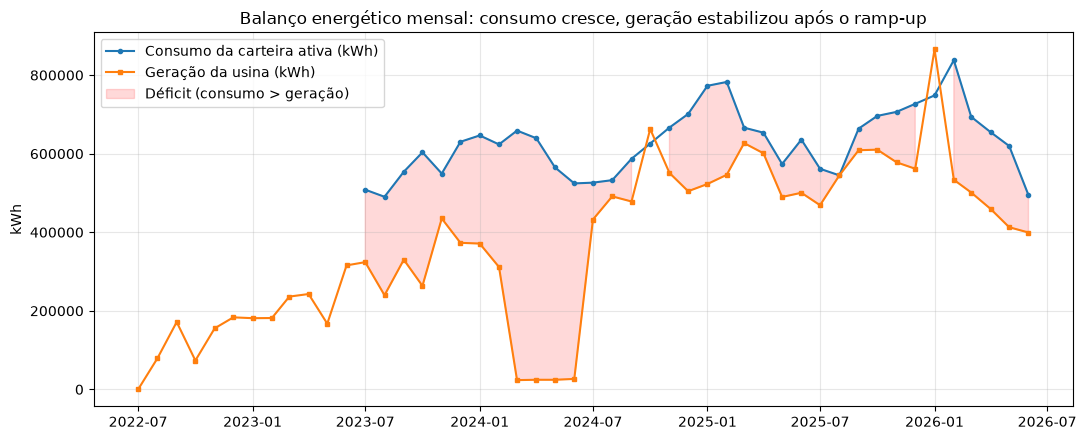

In [19]:
# --- Gráfico: a tendência que sustenta o comunicado ---
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(mensal_c.index, mensal_c.values, marker="o", ms=3, label="Consumo da carteira ativa (kWh)")
ax.plot(mensal_g.index, mensal_g.values, marker="s", ms=3, label="Geração da usina (kWh)")
ax.fill_between(mensal_c.index, mensal_g.reindex(mensal_c.index).values, mensal_c.values,
                where=(mensal_c.values > mensal_g.reindex(mensal_c.index).values),
                alpha=0.15, color="red", label="Déficit (consumo > geração)")
ax.set_title("Balanço energético mensal: consumo cresce, geração estabilizou após o ramp-up")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylabel("kWh")
plt.tight_layout(); plt.show()

### Comunicado à Diretoria da Digital Grid

**De:** Análise de Projetos P&D  |  **Para:** Diretoria  |  **Assunto:** Balanço energético da carteira da Usina Teste e ações para o próximo trimestre

**Diagnóstico.** A carteira opera hoje em **déficit estrutural de geração**. Nos últimos 12 meses (jul/2025 a jun/2026), as UCs ativas consumiram **7,95 milhões de kWh** e a usina gerou **6,54 milhões de kWh**: cobertura de **82%**, um déficit de **1,40 milhão de kWh no ano** (~117 mil kWh/mês).

A tendência é de abertura da tesoura, pois o consumo cresce ano após ano (7,0 → 7,7 → 7,9 milhões de kWh nas três janelas anuais disponíveis), enquanto a geração, encerrado o ramp-up, estabilizou e recua nos meses recentes. O colchão de créditos que vinha absorvendo essa diferença está no fim: as UCs ativas somam **166 mil kWh** de saldo, fôlego de **cerca de 1,4 mês** no ritmo atual de déficit. 

Como agravante, **735 mil kWh** de crédito, o equivalente a **mais de 6 meses de déficit**, estão presos em 10 UCs canceladas, fora da compensação e sujeitos a expiração regulatória. Por fim, há risco de concentração. As 10 maiores UCs respondem por **77%** do consumo, e a maior, sozinha, por **34%**.

**Recomendação para o próximo trimestre.**
1. **Recuperar imediatamente os 735 mil kWh presos** via rebalanceamento das UCs canceladas para as ativas (US4 do backlog). É a ação de maior retorno e custo zero. Oferece mais de 6 meses de fôlego enquanto as ações estruturais maturam.
2. **Recompor a oferta de energia:** investigar a queda de geração dos últimos meses (de um patamar de 560 a 610 mil kWh no último trimestre de 2025 para 399 mil kWh em jun/2026, após um pico atípico em jan/2026), possivelmente degradação, indisponibilidade ou manutenção não programada, e, em paralelo, contratar ou realocar geração adicional na ordem de **150 mil kWh/mês**, suficiente para fechar o déficit médio e ainda constituir reserva operacional de 5% do consumo.
3. **Blindar a receita da carteira:** plano de relacionamento ativo com as Top 10 UCs (77% do consumo) e gatilho comercial de recomposição de carteira em caso de saída, dado que a perda da maior UC alteraria todo o dimensionamento da usina.

Com o rebalanceamento executado no primeiro mês e a recomposição de oferta contratada no trimestre, a carteira volta a operar com cobertura integral antes do esgotamento do colchão de créditos.